# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

In [6]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    object 
 2   Income              164 non-null    object 
 3   Education           164 non-null    object 
 4   Marital Status      164 non-null    object 
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    object 
 7   Credit Score        164 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 10.4+ KB


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [8]:
# 1 — Corrigir Income: remover pontos e trocar vírgula por ponto
df['Income'] = df['Income'].str.replace('.', '', regex=False)
df['Income'] = df['Income'].str.replace(',', '.', regex=False)
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

# 2 — Converter categóricas
col_categoricas = ['Gender', 'Education', 'Marital Status', 'Home Ownership', 'Credit Score']
df[col_categoricas] = df[col_categoricas].astype('category')

# Verificar resultado
df.info()
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Age                 130 non-null    float64 
 1   Gender              164 non-null    category
 2   Income              164 non-null    float64 
 3   Education           164 non-null    category
 4   Marital Status      164 non-null    category
 5   Number of Children  164 non-null    int64   
 6   Home Ownership      164 non-null    category
 7   Credit Score        164 non-null    category
dtypes: category(5), float64(2), int64(1)
memory usage: 5.5 KB
    Age  Gender    Income            Education Marital Status  \
0  25.0  Female   50000.0    Bachelor's Degree         Single   
1  30.0    Male  100000.0      Master's Degree        Married   
2  35.0  Female   75000.0            Doctorate        Married   
3  40.0    Male  125000.0  High School Diploma         Single   
4  45.0 

**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

In [10]:
# Verificar nulos
percentual_nulos = (df.isnull().mean() * 100).sort_values(ascending=False)
print(percentual_nulos)

Age                   20.731707
Gender                 0.000000
Income                 0.000000
Education              0.000000
Marital Status         0.000000
Number of Children     0.000000
Home Ownership         0.000000
Credit Score           0.000000
dtype: float64


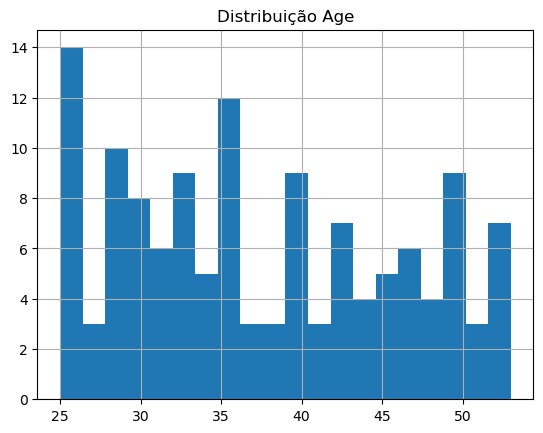

Média: 37.51
Mediana: 36.0


In [12]:
# Verificar distribuição da Age para decidir média ou mediana
df['Age'].hist(bins=20)
plt.title('Distribuição Age')
plt.show()

print('Média:', df['Age'].mean().round(2))
print('Mediana:', df['Age'].median())

In [14]:
# Preencher nulos de Age com a mediana
mediana_age = df['Age'].median()
df['Age'] = df['Age'].fillna(mediana_age)

# Justificativa: A distribuição de Age é irregular e levemente assimétrica.
# A mediana é mais robusta pois não é influenciada pelos valores extremos,
# representando melhor o centro dos dados.

# Confirmar que não há mais nulos
print(df.isnull().sum())

Age                   0
Gender                0
Income                0
Education             0
Marital Status        0
Number of Children    0
Home Ownership        0
Credit Score          0
dtype: int64


**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

In [16]:
# Verificar valores únicos de cada categórica
col_categoricas = ['Gender', 'Education', 'Marital Status', 'Home Ownership', 'Credit Score']

for col in col_categoricas:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Gender ---
Gender
Female    86
Male      78
Name: count, dtype: int64

--- Education ---
Education
Bachelor's Degree      42
Master's Degree        36
Doctorate              31
High School Diploma    30
Associate's Degree     25
Name: count, dtype: int64

--- Marital Status ---
Marital Status
Married    87
Single     77
Name: count, dtype: int64

--- Home Ownership ---
Home Ownership
Owned     111
Rented     53
Name: count, dtype: int64

--- Credit Score ---
Credit Score
High       113
Average     36
Low         15
Name: count, dtype: int64


# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

In [18]:
df.describe()

,Age,Income,Number of Children
count,164.000000,164.000000,164.000000
mean,37.195122,83765.243902,0.652439
std,7.586619,32457.306728,0.883346
min,25.000000,25000.000000,0.000000
25%,31.750000,57500.000000,0.000000
50%,36.000000,83750.000000,0.000000
75%,43.000000,105000.000000,1.000000
max,53.000000,162500.000000,3.000000


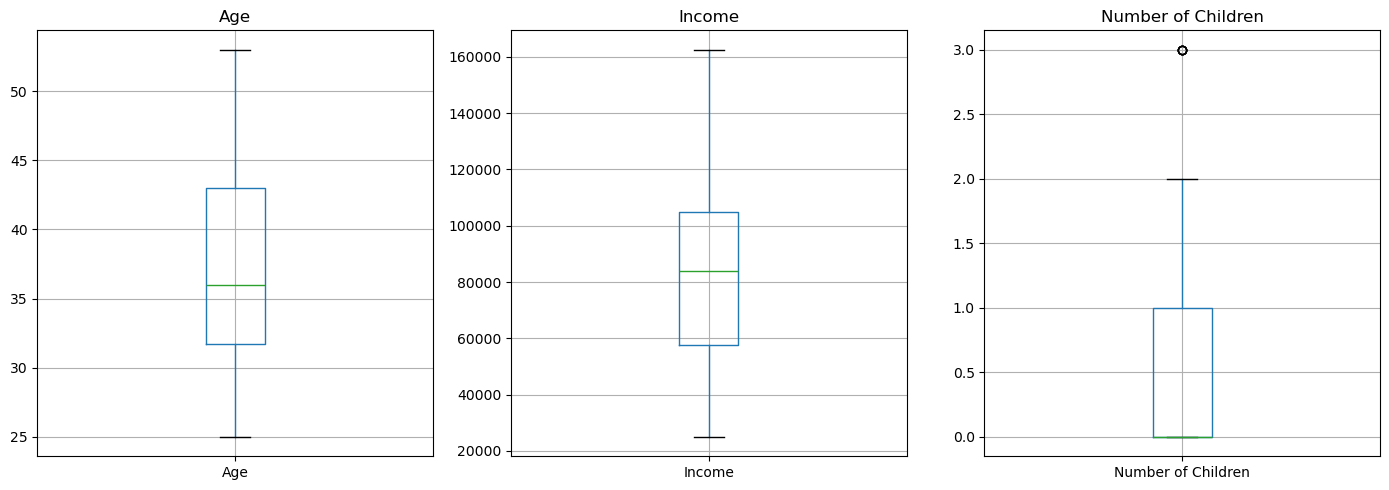

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

df.boxplot(column='Age', ax=axes[0])
axes[0].set_title('Age')

df.boxplot(column='Income', ax=axes[1])
axes[1].set_title('Income')

df.boxplot(column='Number of Children', ax=axes[2])
axes[2].set_title('Number of Children')

plt.tight_layout()
plt.show()

In [22]:
# Verificar quantos clientes têm 3 filhos
print(df['Number of Children'].value_counts())

# Justificativa: O valor 3 é estatisticamente outlier pelo IQR,
# mas representa um comportamento real e legítimo.
# Remover esses registros causaria perda de informação válida.
# Decisão: manter os valores.

Number of Children
0    97
1    32
2    30
3     5
Name: count, dtype: int64


**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

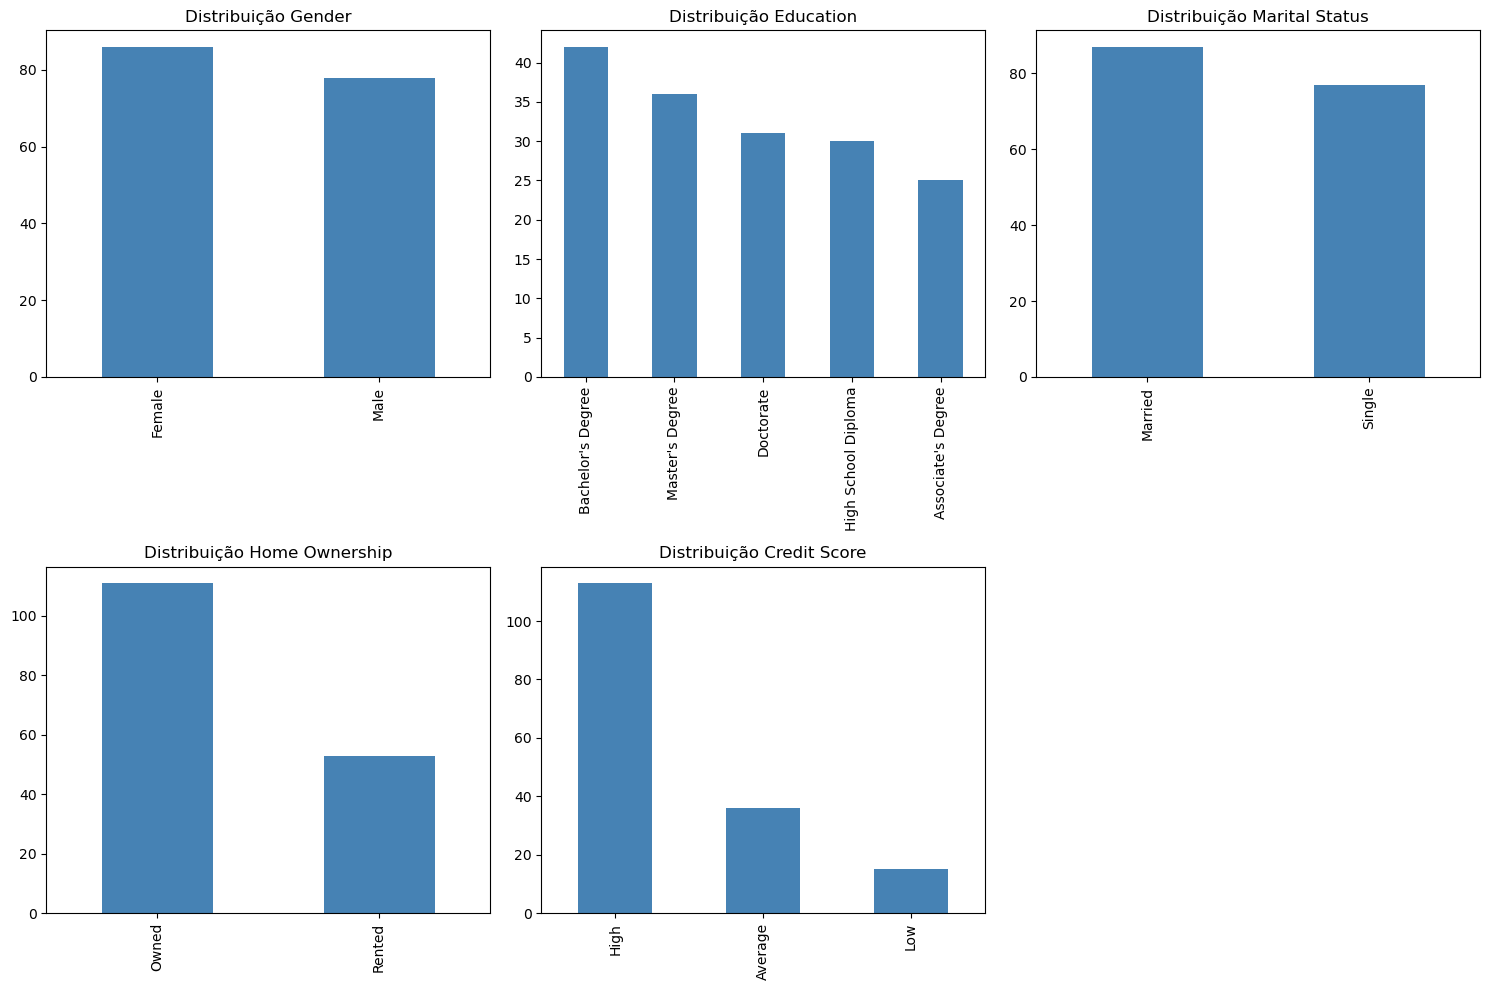

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

col_categoricas = ['Gender', 'Education', 'Marital Status', 'Home Ownership', 'Credit Score']

for i, col in enumerate(col_categoricas):
    ax = axes[i // 3][i % 3]
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Distribuição {col}')
    ax.set_xlabel('')

# Desligar o subplot vazio
axes[1][2].axis('off')

plt.tight_layout()
plt.show()

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

### Etapa 2C - Outliers

A análise dos boxplots identificou apenas um outlier em **Number of Children**,
onde clientes com 3 filhos são estatisticamente outliers pelo critério IQR.

No entanto, apenas 5 clientes se enquadram nessa situação e o valor é
perfeitamente plausível no contexto real. Remover esses registros causaria
perda de informação legítima sem benefício para o modelo.

**Decisão: manter todos os valores.**

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



C:\Users\Cliente\AppData\Local\Temp\ipykernel_18656\2797176727.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Education')['Credit Score'].value_counts(normalize=True).mul(100).unstack().plot(
C:\Users\Cliente\AppData\Local\Temp\ipykernel_18656\2797176727.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Home Ownership')['Credit Score'].value_counts(normalize=True).mul(100).unstack().plot(


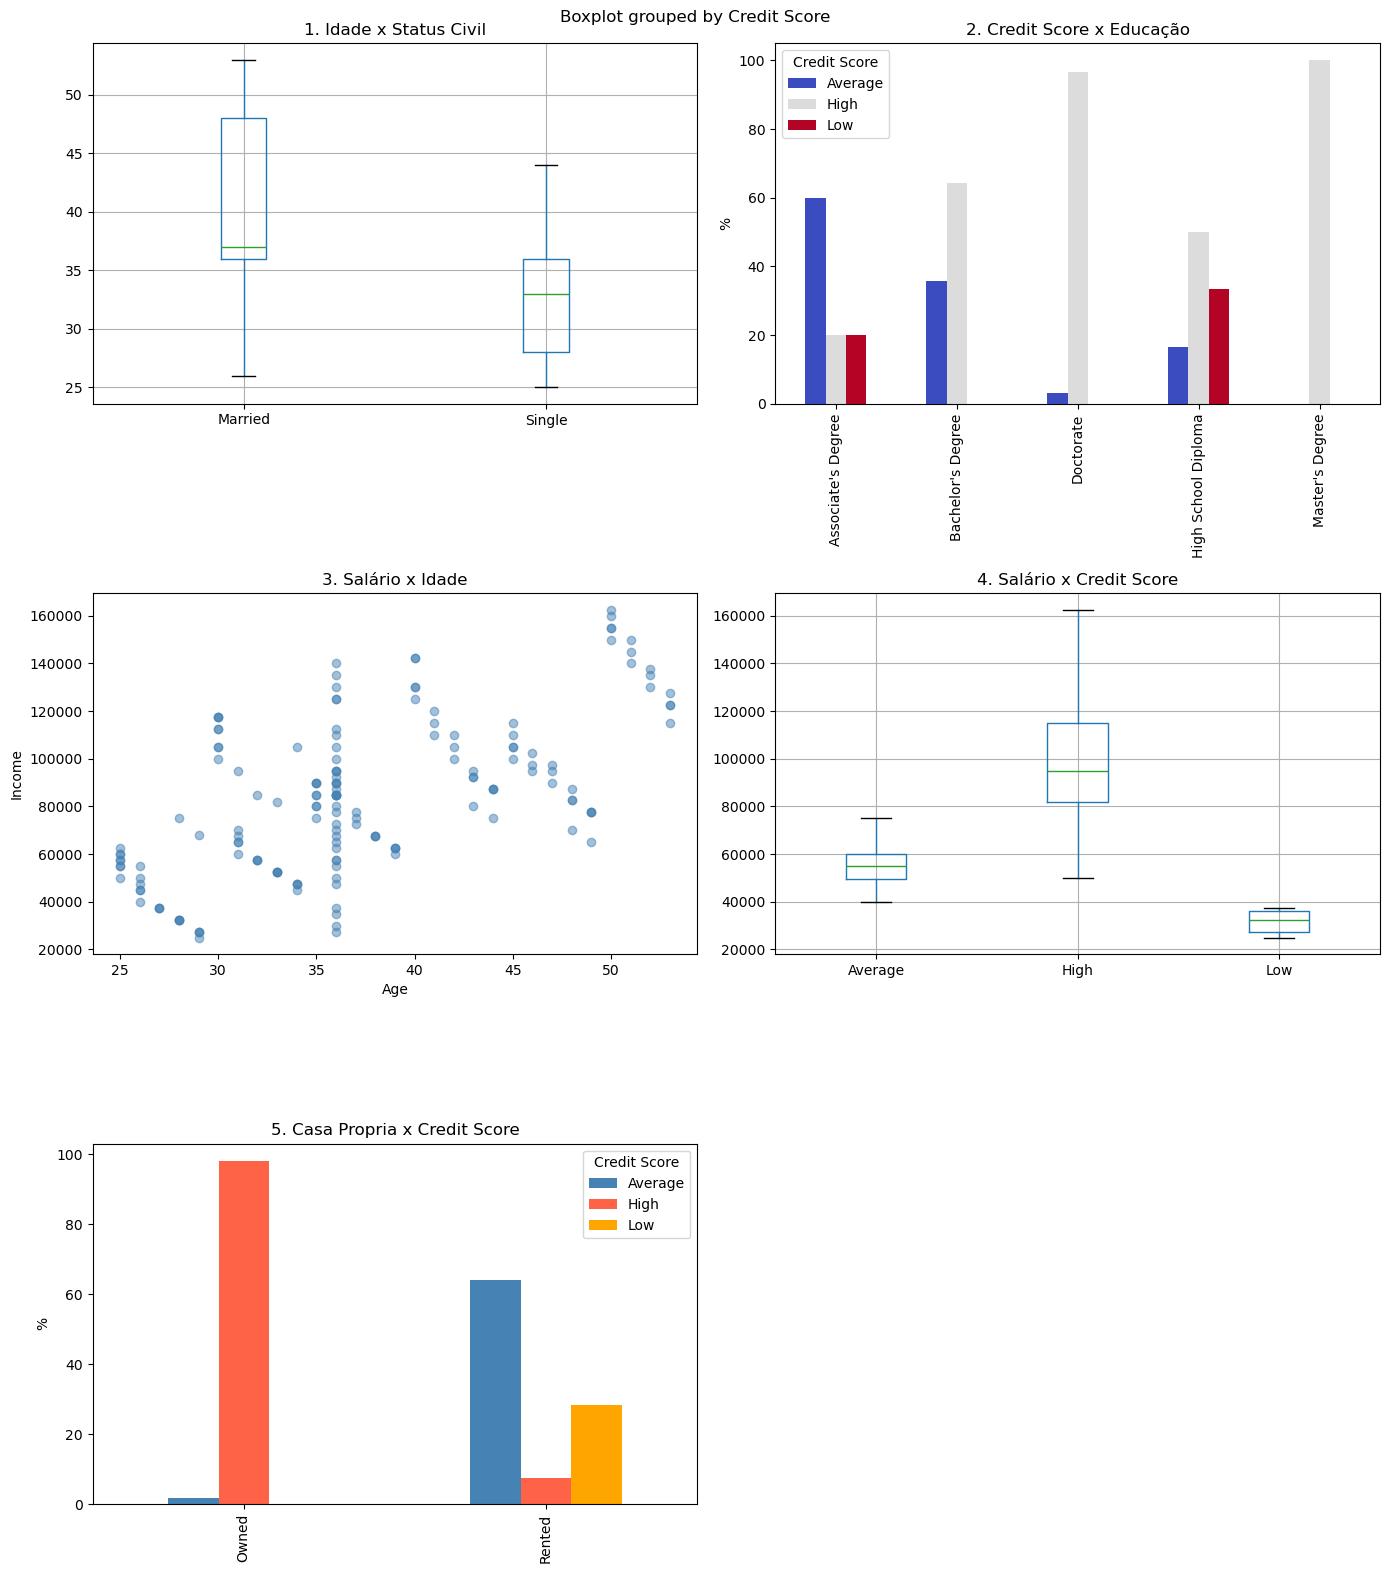

In [27]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))

# 1 — Idade x Status Civil
df.boxplot(column='Age', by='Marital Status', ax=axes[0,0])
axes[0,0].set_title('1. Idade x Status Civil')
axes[0,0].set_xlabel('')

# 2 — Credit Score x Educação
df.groupby('Education')['Credit Score'].value_counts(normalize=True).mul(100).unstack().plot(
    kind='bar', ax=axes[0,1], colormap='coolwarm')
axes[0,1].set_title('2. Credit Score x Educação')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('%')

# 3 — Salário x Idade
axes[1,0].scatter(df['Age'], df['Income'], alpha=0.5, color='steelblue')
axes[1,0].set_title('3. Salário x Idade')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Income')

# 4 — Salário x Credit Score
df.boxplot(column='Income', by='Credit Score', ax=axes[1,1])
axes[1,1].set_title('4. Salário x Credit Score')
axes[1,1].set_xlabel('')

# 5 — Home Ownership x Credit Score
df.groupby('Home Ownership')['Credit Score'].value_counts(normalize=True).mul(100).unstack().plot(
    kind='bar', ax=axes[2,0], color=['steelblue', 'tomato', 'orange'])
axes[2,0].set_title('5. Casa Propria x Credit Score')
axes[2,0].set_xlabel('')
axes[2,0].set_ylabel('%')

axes[2,1].axis('off')

plt.tight_layout()
plt.show()

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

C:\Users\Cliente\AppData\Local\Temp\ipykernel_18656\4172584234.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Gender')['Credit Score'].value_counts(normalize=True).mul(100).unstack().plot(


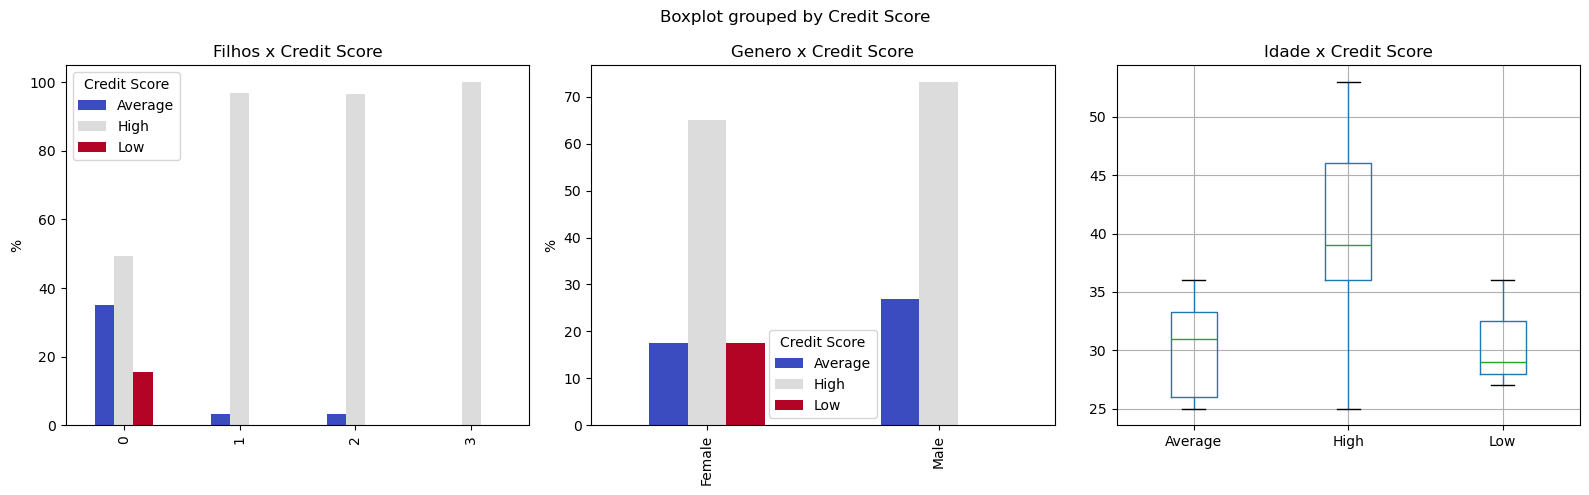

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1 — Número de Filhos x Credit Score
df.groupby('Number of Children')['Credit Score'].value_counts(normalize=True).mul(100).unstack().plot(
    kind='bar', ax=axes[0], colormap='coolwarm')
axes[0].set_title('Filhos x Credit Score')
axes[0].set_xlabel('')
axes[0].set_ylabel('%')

# 2 — Gênero x Credit Score
df.groupby('Gender')['Credit Score'].value_counts(normalize=True).mul(100).unstack().plot(
    kind='bar', ax=axes[1], colormap='coolwarm')
axes[1].set_title('Genero x Credit Score')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')

# 3 — Idade x Credit Score
df.boxplot(column='Age', by='Credit Score', ax=axes[2])
axes[2].set_title('Idade x Credit Score')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

### Etapa 2D - Análise Bivariada

**1. Idade x Status Civil**
Casados tendem a ser mais velhos (mediana ~38) que solteiros (mediana ~33).
Faz sentido, pessoas tendem a se casar com o passar da idade.

**2. Credit Score x Educação**
Quanto maior a escolaridade, melhor o score. Doutorado e Master's Degree
concentram mais scores High, enquanto High School Diploma tem maior proporção
de scores Low e Average.

**3. Salário x Idade**
Não há tendência clara entre salário e idade, a nuvem de pontos está
espalhada sem padrão linear. Salário não cresce com a idade nessa base.

**4. Salário x Credit Score**
Variável com forte impacto. Clientes com score High ganham em média ~85k,
Average ~55k e Low ~35k. O salário é um forte preditor do Credit Score.

**5. Casa Própria x Credit Score**
Quase 100% dos clientes que alugam têm score Average ou Low.
Clientes com casa própria dominam o score High. Casa própria está
fortemente associada a um bom score de crédito.

### Etapa 2E - Perguntas Extras

**1. Número de Filhos x Credit Score**
Clientes sem filhos têm maior variação de score, incluindo Low e Average.
Clientes com 1, 2 ou 3 filhos têm quase 100% de score High, ter filhos
pode indicar maior estabilidade financeira e responsabilidade.

**2. Gênero x Credit Score**
Mulheres têm ~65% de score High enquanto homens chegam a ~72%.
A diferença é pequena mas homens apresentam score High levemente
superior nessa base.

**3. Idade x Credit Score**
Clientes com score High são mais velhos (mediana ~38) enquanto
scores Average e Low concentram clientes mais jovens (~30 anos).
Idade mais avançada está associada a maior estabilidade financeira
e melhor score de crédito.ade financeira
e melhor score de crédito.

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

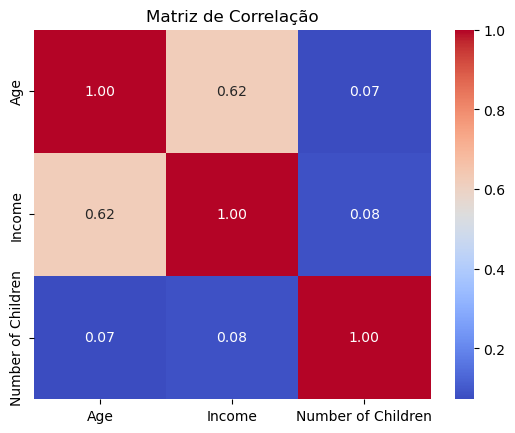

In [33]:
# Selecionar apenas colunas numéricas
correlacao = df[['Age', 'Income', 'Number of Children']].corr()

# Plotar matriz de correlação
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

### Etapa 3B - Análise de Correlação

A única correlação relevante encontrada foi entre **Age e Income** (0.62),
considerada uma correlação moderada a alta.

Faz sentido do ponto de vista de negócio: pessoas mais velhas tendem a ter
mais tempo de carreira e experiência acumulada, o que naturalmente leva a
salários mais altos.

As demais correlações (Age x Children e Income x Children) são praticamente
nulas, indicando que o número de filhos não depende da idade nem do salário
nessa base.

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

col_para_encodar = ['Gender', 'Education', 'Marital Status', 'Home Ownership', 'Credit Score']

for col in col_para_encodar:
    df[col + '_encoded'] = le.fit_transform(df[col])

# Remover colunas categóricas originais
df = df.drop(columns=col_para_encodar)

print(df.head())
print(df.info())

    Age    Income  Number of Children  Gender_encoded  Education_encoded  \
0  25.0   50000.0                   0               0                  1   
1  30.0  100000.0                   2               1                  4   
2  35.0   75000.0                   1               0                  2   
3  40.0  125000.0                   0               1                  3   
4  45.0  100000.0                   3               0                  1   

   Marital Status_encoded  Home Ownership_encoded  Credit Score_encoded  
0                       1                       1                     1  
1                       0                       0                     1  
2                       0                       0                     1  
3                       1                       0                     1  
4                       0                       0                     1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 colum

**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

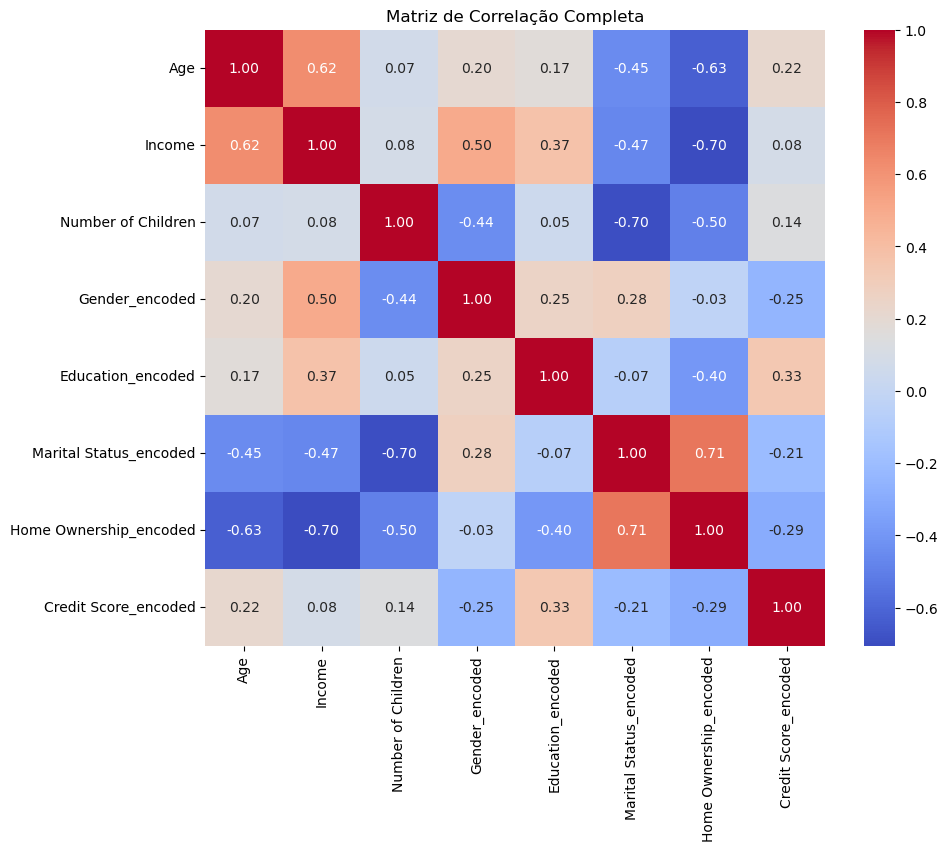

In [38]:
correlacao2 = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlacao2, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação Completa')
plt.show()

### Etapa 3D - Correlação Completa

Com as variáveis categóricas encodadas, novas correlações relevantes surgiram:

**Novas correlações fortes:**

- Home Ownership x Income (-0.70): clientes com casa própria tendem a
  ter renda maior. O sinal negativo reflete a codificação (0=Owned, 1=Rented).

- Home Ownership x Marital Status (0.71): casados tendem a ter casa própria.
  Faz sentido, casais costumam buscar mais estabilidade de moradia.

- Home Ownership x Age (-0.63): clientes mais velhos tendem a ter casa própria.

- Number of Children x Marital Status (-0.70): casados tendem a ter mais filhos.
  Correlação esperada e coerente com o comportamento real.

- Income x Gender (0.50): homens tendem a ter renda maior nessa base.

**Relação com Credit Score:**
A correlação direta do Credit Score com as demais variáveis ainda é moderada,
o que indica que o modelo precisará combinar múltiplas variáveis para prever
bem o score.

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [41]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Credit Score_encoded'])
y = df['Credit Score_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)

Treino: (131, 7)
Teste: (33, 7)


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

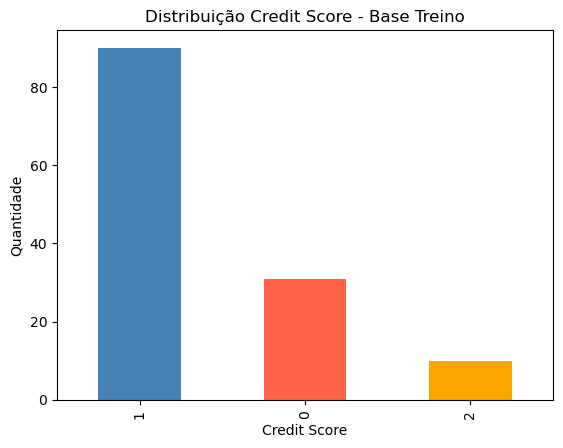

Credit Score_encoded
1    90
0    31
2    10
Name: count, dtype: int64

% por classe:
Credit Score_encoded
1    68.7
0    23.7
2     7.6
Name: proportion, dtype: float64


In [43]:
y_train.value_counts().plot(kind='bar', color=['steelblue', 'tomato', 'orange'])
plt.title('Distribuição Credit Score - Base Treino')
plt.xlabel('Credit Score')
plt.ylabel('Quantidade')
plt.show()

print(y_train.value_counts())
print('\n% por classe:')
print(y_train.value_counts(normalize=True).mul(100).round(1))

### Etapa 3G - Balanceamento do Credit Score

A base de treino está claramente desbalanceada:

- Classe 1 (High): 90 registros (68.7%)
- Classe 0 (Average): 31 registros (23.7%)
- Classe 2 (Low): 10 registros (7.6%)

Um modelo treinado com esses dados tenderia a prever quase sempre
"High", ignorando as classes minoritárias. É necessário realizar
o balanceamento antes de treinar.

**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

Antes do balanceamento:
Credit Score_encoded
1    90
0    31
2    10
Name: count, dtype: int64

Depois do balanceamento:
Credit Score_encoded
1    90
0    90
2    90
Name: count, dtype: int64


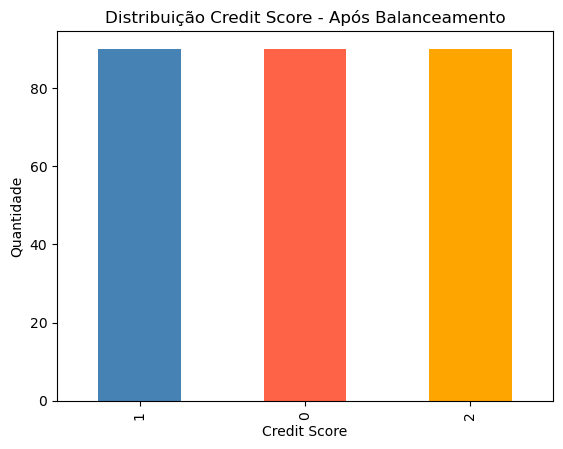

In [46]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('Antes do balanceamento:')
print(y_train.value_counts())

print('\nDepois do balanceamento:')
print(y_train_bal.value_counts())

# Plotar depois
y_train_bal.value_counts().plot(kind='bar', color=['steelblue', 'tomato', 'orange'])
plt.title('Distribuição Credit Score - Após Balanceamento')
plt.xlabel('Credit Score')
plt.ylabel('Quantidade')
plt.show()

### Etapa 3H - Balanceamento com SMOTE

O SMOTE (Synthetic Minority Oversampling Technique) foi aplicado
apenas na base de treino, gerando registros sintéticos para as
classes minoritárias até igualar todas as classes.

Resultado:
- Antes: High=90, Average=31, Low=10
- Depois: High=90, Average=90, Low=90

A base de teste foi mantida intacta, preservando a distribuição
real dos dados para uma avaliação justa do modelo.